Using device: cpu
Train: torch.Size([1760, 3, 48, 48]), Val: torch.Size([320, 3, 48, 48]), Test: torch.Size([400, 3, 48, 48])
Total trainable parameters: 684680
Epoch  1/18 | train_loss=1.1808 train_acc=0.5472 | val_loss=0.4073 val_acc=0.8438
Epoch  2/18 | train_loss=0.4043 train_acc=0.8170 | val_loss=0.2346 val_acc=0.8875
Epoch  3/18 | train_loss=0.2726 train_acc=0.8648 | val_loss=0.2045 val_acc=0.8812
Epoch  4/18 | train_loss=0.2438 train_acc=0.8665 | val_loss=0.2609 val_acc=0.8531
Epoch  5/18 | train_loss=0.2278 train_acc=0.8693 | val_loss=0.2345 val_acc=0.8656
Epoch  6/18 | train_loss=0.2264 train_acc=0.8733 | val_loss=0.1948 val_acc=0.8656
Epoch  7/18 | train_loss=0.2131 train_acc=0.8835 | val_loss=0.1872 val_acc=0.8719
Epoch  8/18 | train_loss=0.2208 train_acc=0.8801 | val_loss=0.2095 val_acc=0.8688
Epoch  9/18 | train_loss=0.1929 train_acc=0.8983 | val_loss=0.1796 val_acc=0.8844
Epoch 10/18 | train_loss=0.1850 train_acc=0.9028 | val_loss=0.1625 val_acc=0.9031
Epoch 11/18 | train

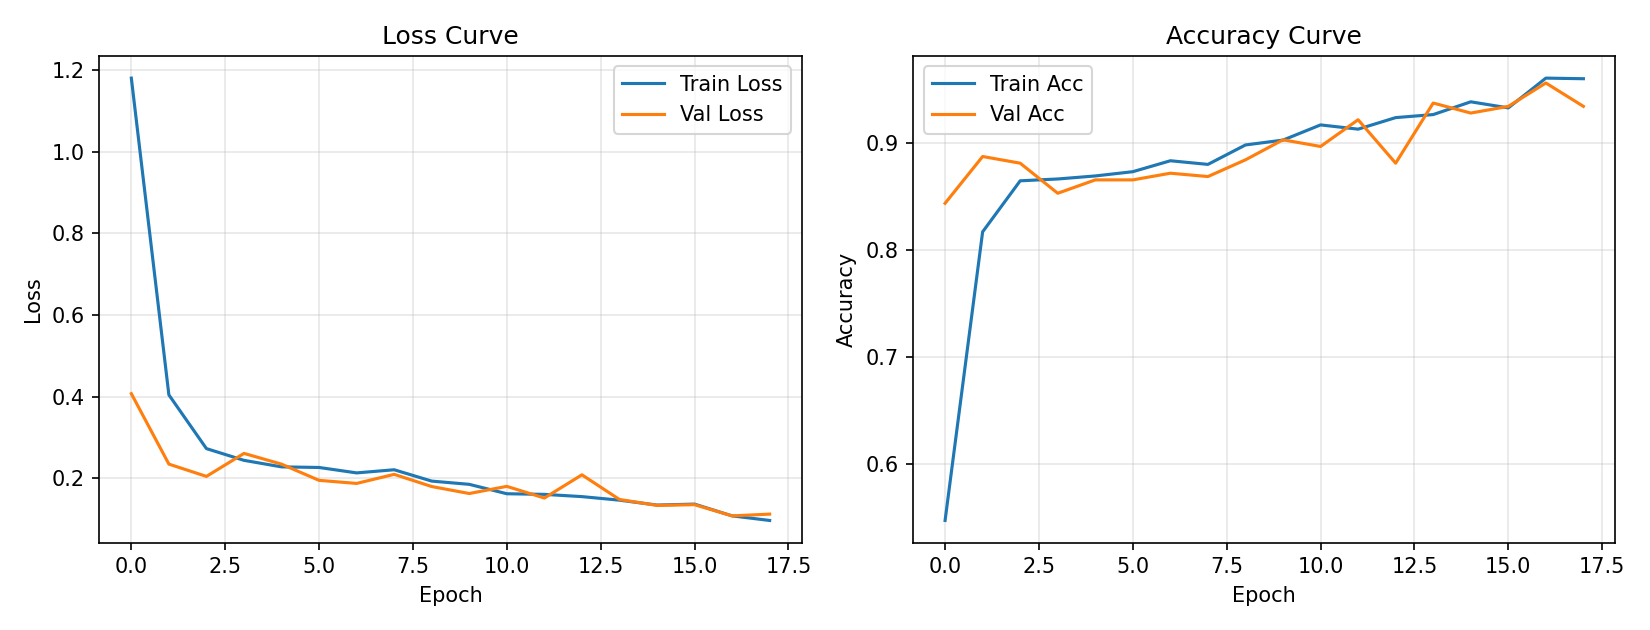

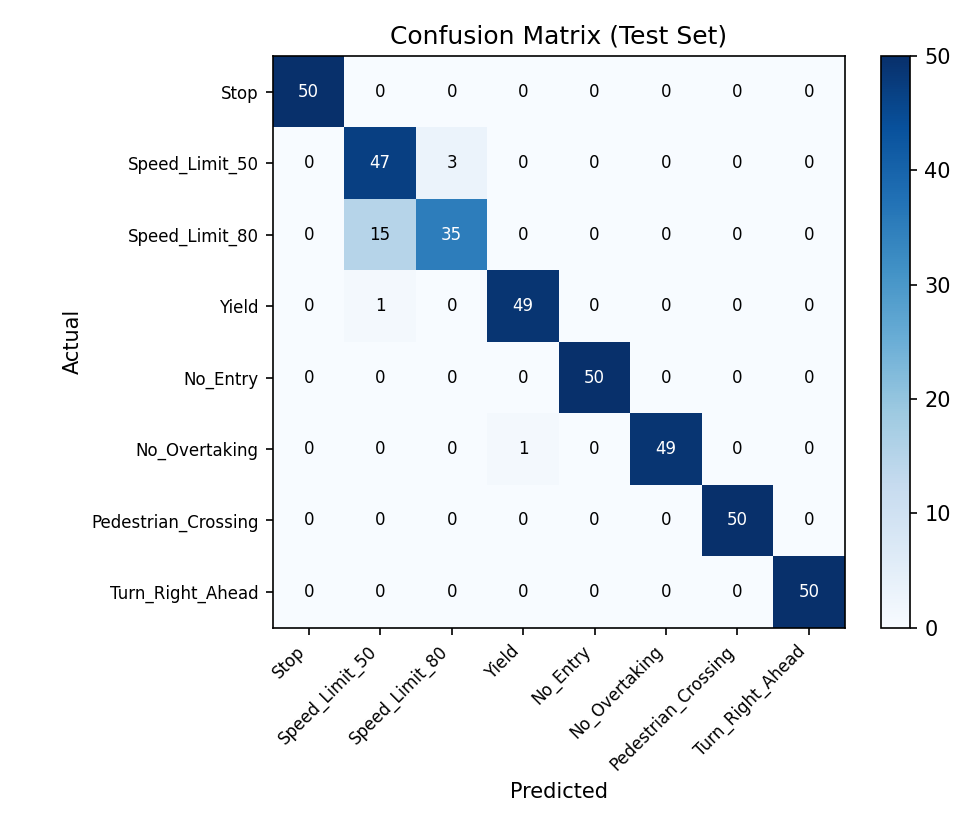

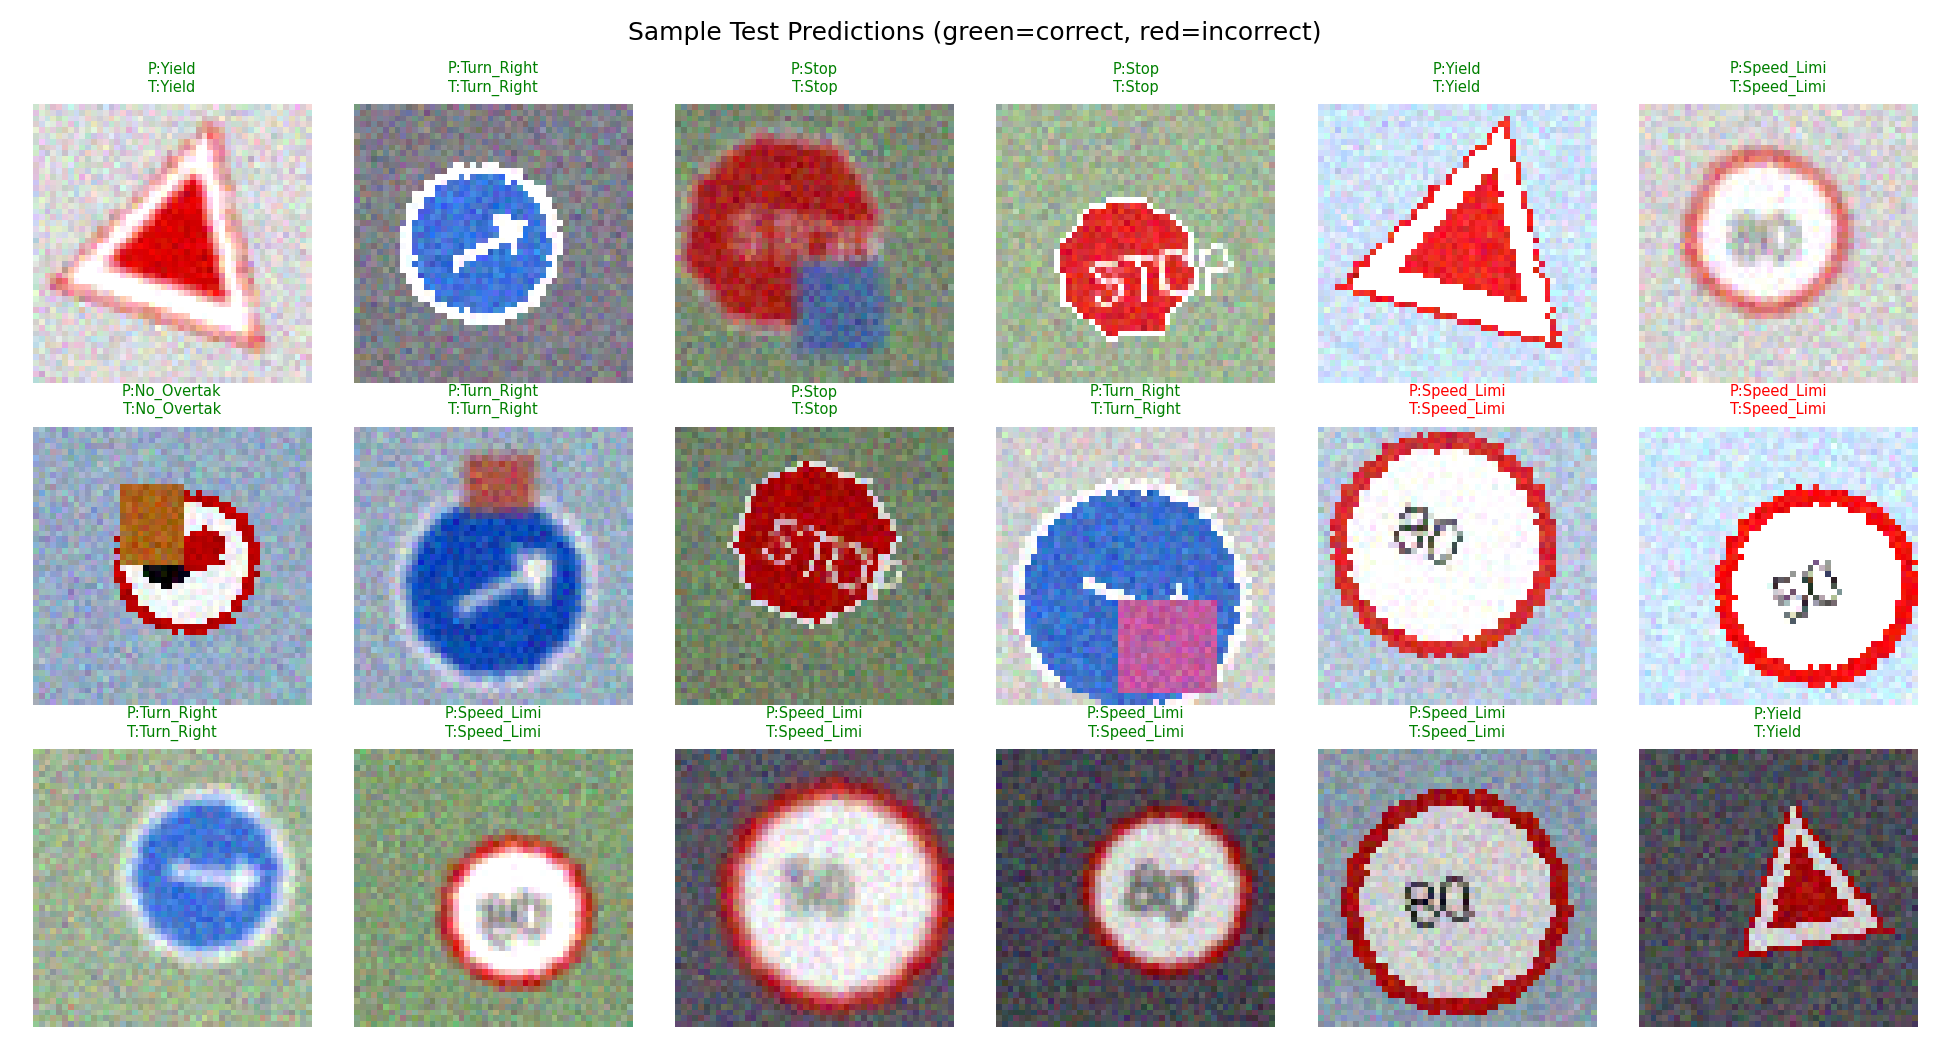

In [22]:
# =============================================================================
# CNN-Based Traffic Sign Recognition System — Google Colab notebook script
# MLA0408 Deep Learning Assignment
#
# HOW TO RUN IN COLAB:
#   1. Open https://colab.research.google.com -> New Notebook
#   2. Paste this entire file into one cell (or split at the "# %%" markers
#      into separate cells) and Run All.
#   3. Torch, NumPy, PIL, scikit-learn and Matplotlib are preinstalled on
#      Colab, so no pip install is needed. GPU is optional (Runtime > Change
#      runtime type > GPU) — the model also trains fine on CPU in ~1-2 min.
#   4. Generated figures (training_curves.png, confusion_matrix.png,
#      sample_predictions.png) and metrics.json are saved to /content/outputs
#      and can be downloaded from the Colab file browser on the left.
# =============================================================================

# %% [1] Imports and setup
import os, time, json, random
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

os.makedirs("outputs", exist_ok=True)
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# %% [2] Dataset generation (synthetic traffic-sign images)
"""
Synthetic traffic-sign dataset generator.
Creates procedurally-drawn traffic sign images (6 classes) with random
rotation, scale, translation, brightness and noise augmentation, so the
CNN pipeline below can be trained and evaluated end-to-end without
requiring an external dataset download.
"""
IMG_SIZE = 48
CLASSES = ["Stop", "Speed_Limit_50", "Speed_Limit_80", "Yield", "No_Entry",
           "No_Overtaking", "Pedestrian_Crossing", "Turn_Right_Ahead"]
NUM_CLASSES = len(CLASSES)


def _base_canvas():
    bg = random.choice([(200, 200, 200), (170, 190, 210), (140, 160, 130), (100, 100, 110)])
    img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), bg)
    return img


def draw_stop(draw, cx, cy, r):
    pts = []
    for i in range(8):
        ang = np.pi / 8 + i * np.pi / 4
        pts.append((cx + r * np.cos(ang), cy + r * np.sin(ang)))
    draw.polygon(pts, fill=(200, 20, 20), outline=(255, 255, 255))
    draw.text((cx - r * 0.55, cy - r * 0.3), "STOP", fill=(255, 255, 255))


def draw_speed_limit(draw, cx, cy, r):
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(255, 255, 255), outline=(200, 20, 20), width=max(2, int(r * 0.18)))
    draw.text((cx - r * 0.45, cy - r * 0.35), "50", fill=(20, 20, 20))


def draw_yield(draw, cx, cy, r):
    pts = [(cx, cy - r), (cx - r, cy + r * 0.8), (cx + r, cy + r * 0.8)]
    draw.polygon(pts, fill=(255, 255, 255), outline=(200, 20, 20))
    draw.polygon([(cx, cy - r * 0.55), (cx - r * 0.55, cy + r * 0.5), (cx + r * 0.55, cy + r * 0.5)],
                 fill=(200, 20, 20))


def draw_no_entry(draw, cx, cy, r):
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(200, 20, 20), outline=(255, 255, 255), width=max(2, int(r * 0.15)))
    draw.rectangle([cx - r * 0.6, cy - r * 0.18, cx + r * 0.6, cy + r * 0.18], fill=(255, 255, 255))


def draw_pedestrian(draw, cx, cy, r):
    pts = [(cx, cy - r), (cx + r, cy), (cx, cy + r), (cx - r, cy)]
    draw.polygon(pts, fill=(255, 220, 60), outline=(20, 20, 20))
    draw.ellipse([cx - r * 0.12, cy - r * 0.45, cx + r * 0.12, cy - r * 0.2], fill=(20, 20, 20))
    draw.line([cx, cy - r * 0.2, cx, cy + r * 0.25], fill=(20, 20, 20), width=max(1, int(r * 0.1)))
    draw.line([cx, cy + r * 0.25, cx - r * 0.2, cy + r * 0.55], fill=(20, 20, 20), width=max(1, int(r * 0.1)))
    draw.line([cx, cy + r * 0.25, cx + r * 0.2, cy + r * 0.55], fill=(20, 20, 20), width=max(1, int(r * 0.1)))


def draw_turn_right(draw, cx, cy, r):
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(30, 90, 200), outline=(255, 255, 255), width=max(2, int(r * 0.12)))
    draw.line([cx - r * 0.4, cy, cx + r * 0.35, cy], fill=(255, 255, 255), width=max(2, int(r * 0.14)))
    draw.polygon([(cx + r * 0.35, cy - r * 0.25), (cx + r * 0.35, cy + r * 0.25), (cx + r * 0.65, cy)],
                 fill=(255, 255, 255))


def draw_speed_limit_80(draw, cx, cy, r):
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(255, 255, 255), outline=(200, 20, 20), width=max(2, int(r * 0.18)))
    draw.text((cx - r * 0.45, cy - r * 0.35), "80", fill=(20, 20, 20))


def draw_no_overtaking(draw, cx, cy, r):
    draw.ellipse([cx - r, cy - r, cx + r, cy + r], fill=(255, 255, 255), outline=(200, 20, 20), width=max(2, int(r * 0.16)))
    draw.ellipse([cx - r * 0.55, cy - r * 0.35, cx + r * 0.1, cy + r * 0.15], fill=(40, 40, 40))
    draw.ellipse([cx - r * 0.05, cy - r * 0.35, cx + r * 0.6, cy + r * 0.15], fill=(200, 20, 20))


_DRAW_FNS = [draw_stop, draw_speed_limit, draw_speed_limit_80, draw_yield, draw_no_entry,
             draw_no_overtaking, draw_pedestrian, draw_turn_right]


def generate_sample(label):
    img = _base_canvas()
    draw = ImageDraw.Draw(img)
    cx = IMG_SIZE / 2 + random.uniform(-6, 6)
    cy = IMG_SIZE / 2 + random.uniform(-6, 6)
    r = IMG_SIZE * random.uniform(0.24, 0.42)  # wider scale range -> harder
    _DRAW_FNS[label](draw, cx, cy, r)

    arr = np.array(img).astype(np.float32)

    # random rotation via simple affine (PIL)
    angle = random.uniform(-28, 28)
    img2 = Image.fromarray(arr.astype(np.uint8)).rotate(angle, fillcolor=tuple(int(x) for x in arr[0, 0]))
    img_pil = img2

    # random partial occlusion (simulates dirt / glare / obstruction)
    if random.random() < 0.35:
        odraw = ImageDraw.Draw(img_pil)
        ox, oy = random.randint(0, IMG_SIZE - 12), random.randint(0, IMG_SIZE - 12)
        ow, oh = random.randint(8, 16), random.randint(8, 16)
        occ_color = tuple(random.randint(60, 200) for _ in range(3))
        odraw.rectangle([ox, oy, ox + ow, oy + oh], fill=occ_color)

    # motion blur (simulate low-quality dashboard camera capture)
    if random.random() < 0.4:
        img_pil = img_pil.filter(ImageFilter.BoxBlur(random.uniform(0.5, 1.6)))

    arr = np.array(img_pil).astype(np.float32)

    # brightness / contrast jitter (illumination variation)
    arr = (arr - 127.5) * random.uniform(0.7, 1.3) + 127.5 * random.uniform(0.75, 1.25)
    # gaussian sensor noise
    arr = arr + np.random.normal(0, 14, arr.shape)
    arr = np.clip(arr, 0, 255)
    return arr.astype(np.uint8)


def make_dataset(n_per_class, seed=0):
    random.seed(seed)
    np.random.seed(seed)
    X, y = [], []
    for label in range(NUM_CLASSES):
        for _ in range(n_per_class):
            X.append(generate_sample(label))
            y.append(label)
    X = np.stack(X).astype(np.float32) / 255.0
    y = np.array(y, dtype=np.int64)
    perm = np.random.permutation(len(X))
    return X[perm], y[perm]


# %% [3] Build CNN, train, evaluate, plot results
# ---------------- Data ----------------
X_train, y_train = make_dataset(n_per_class=220, seed=1)
X_val, y_val = make_dataset(n_per_class=40, seed=2)
X_test, y_test = make_dataset(n_per_class=50, seed=3)

def to_tensor(X, y):
    Xt = torch.tensor(X).permute(0, 3, 1, 2)  # NHWC -> NCHW
    yt = torch.tensor(y)
    return Xt, yt

Xtr, ytr = to_tensor(X_train, y_train)
Xva, yva = to_tensor(X_val, y_val)
Xte, yte = to_tensor(X_test, y_test)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(Xva, yva), batch_size=64)
test_loader = DataLoader(TensorDataset(Xte, yte), batch_size=64)

print(f"Train: {Xtr.shape}, Val: {Xva.shape}, Test: {Xte.shape}")

# ---------------- Model ----------------
class TrafficSignCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),   # 48->24
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 24->12
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2) # 12->6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TrafficSignCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {n_params}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

# ---------------- Train ----------------
EPOCHS = 18
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

start = time.time()
for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    train_loss = running_loss / total
    train_acc = correct / total

    model.eval()
    vloss, vcorrect, vtotal = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            loss = criterion(out, yb)
            vloss += loss.item() * xb.size(0)
            vcorrect += (out.argmax(1) == yb).sum().item()
            vtotal += xb.size(0)
    val_loss = vloss / vtotal
    val_acc = vcorrect / vtotal
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"Epoch {epoch+1:2d}/{EPOCHS} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

train_time = time.time() - start

# ---------------- Test evaluation ----------------
model.eval()
all_preds, all_true = [], []
t0 = time.time()
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        preds = out.argmax(1)
        all_preds.extend(preds.tolist())
        all_true.extend(yb.tolist())
inference_time_per_image = (time.time() - t0) / len(all_true) * 1000  # ms

test_acc = accuracy_score(all_true, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_true, all_preds, average="macro", zero_division=0)
cm = confusion_matrix(all_true, all_preds)

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Macro Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")
print(f"Avg inference time/image: {inference_time_per_image:.3f} ms")

# per-class metrics
p_c, r_c, f_c, support = precision_recall_fscore_support(all_true, all_preds, average=None, zero_division=0)

metrics = {
    "n_params": n_params,
    "train_time_sec": round(train_time, 2),
    "test_accuracy": round(test_acc, 4),
    "macro_precision": round(precision, 4),
    "macro_recall": round(recall, 4),
    "macro_f1": round(f1, 4),
    "inference_ms_per_image": round(inference_time_per_image, 3),
    "per_class": {CLASSES[i]: {"precision": round(p_c[i], 3), "recall": round(r_c[i], 3),
                                "f1": round(f_c[i], 3), "support": int(support[i])}
                  for i in range(NUM_CLASSES)}
}
with open("outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(json.dumps(metrics, indent=2))

# ---------------- Plots ----------------
# 1. Training curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curve"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy Curve"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/training_curves.png", dpi=150)
plt.close()

# 2. Confusion matrix
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title("Confusion Matrix (Test Set)")
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.close()

# 3. Sample predictions grid
fig, axes = plt.subplots(3, 6, figsize=(13, 7))
idxs = np.random.choice(len(Xte), 18, replace=False)
model.eval()
with torch.no_grad():
    for ax, idx in zip(axes.flat, idxs):
        img = Xte[idx].permute(1, 2, 0).numpy()
        pred = model(Xte[idx:idx+1].to(device)).argmax(1).item()
        true = yte[idx].item()
        ax.imshow(img)
        color = "green" if pred == true else "red"
        ax.set_title(f"P:{CLASSES[pred][:10]}\nT:{CLASSES[true][:10]}", fontsize=7, color=color)
        ax.axis("off")
plt.suptitle("Sample Test Predictions (green=correct, red=incorrect)")
plt.tight_layout()
plt.savefig("outputs/sample_predictions.png", dpi=150)
plt.close()

print("\nSaved plots to outputs/: training_curves.png, confusion_matrix.png, sample_predictions.png")


# %% [4] Display saved figures inline in Colab
from PIL import Image as PILImage
for fname in ['training_curves.png', 'confusion_matrix.png', 'sample_predictions.png']:
    display(PILImage.open(f'outputs/{fname}'))

# %% [5] (Optional) Download outputs as a zip in Colab
# from google.colab import files
# import shutil
# shutil.make_archive('traffic_sign_outputs', 'zip', 'outputs')
# files.download('traffic_sign_outputs.zip')